In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

In [2]:
df1 = pd.read_csv('df1_preprocessed.csv')
df2 = pd.read_csv('df2_preprocessed.csv')
df3 = pd.read_csv('df3_preprocessed.csv')

## Dataset 1 - Diabetes

In [3]:
# keep only clear diabetic vs not diabetic rows
df1 = df1[df1['DIABETE4'].isin([0, 1])].dropna()

X1 = df1.drop(columns=['DIABETE4', '_RFCHOL3'])
y1 = df1['DIABETE4']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=0)

scaler = StandardScaler()
X1_train = pd.DataFrame(scaler.fit_transform(X1_train), columns=X1.columns)
X1_test = pd.DataFrame(scaler.transform(X1_test), columns=X1.columns)

print(X1_train.shape, X1_test.shape)
print('class balance:', y1.value_counts(normalize=True).round(2).to_dict())

(206780, 17) (51696, 17)
class balance: {0.0: 0.85, 1.0: 0.15}


In [4]:
# baseline linear regression
lr1 = LinearRegression()
lr1.fit(X1_train, y1_train)

preds = lr1.predict(X1_test)
preds_binary = (preds >= 0.5).astype(int)

print(classification_report(y1_test, preds_binary))
print('AUC:', round(roc_auc_score(y1_test, preds), 4))

              precision    recall  f1-score   support

         0.0       0.86      0.99      0.92     43936
         1.0       0.61      0.05      0.10      7760

    accuracy                           0.85     51696
   macro avg       0.74      0.52      0.51     51696
weighted avg       0.82      0.85      0.80     51696

AUC: 0.8037


In [5]:
# top features by coefficient
coefs = pd.Series(lr1.coef_, index=X1_train.columns)
coefs.abs().sort_values(ascending=False).head(10)

GENHLTH     0.051224
_RFHYPE6    0.045361
_BMI5       0.044816
_AGEG5YR    0.035118
_MICHD      0.022329
DIFFWALK    0.017911
EXERANY2    0.013182
_INCOMG1    0.012474
_CHOLCH3    0.011450
_SEX        0.010542
dtype: float64

In [6]:
# ridge regression
# adds L2 penalty - shrinks coefficients to reduce overfitting
# good when many features are correlated
ridge1 = Ridge(alpha=1.0)
ridge1.fit(X1_train, y1_train)

preds_ridge = ridge1.predict(X1_test)
print('Ridge AUC:', round(roc_auc_score(y1_test, preds_ridge), 4))

Ridge AUC: 0.8037


In [7]:
# lasso regression
# adds L1 penalty - can zero out irrelevant features entirely
# acts as automatic feature selection
lasso1 = Lasso(alpha=0.001)
lasso1.fit(X1_train, y1_train)

preds_lasso = lasso1.predict(X1_test)
print('Lasso AUC:', round(roc_auc_score(y1_test, preds_lasso), 4))
print('features kept:', (lasso1.coef_ != 0).sum())
print('features zeroed out:', (lasso1.coef_ == 0).sum())

Lasso AUC: 0.8037
features kept: 16
features zeroed out: 1


In [8]:
# elastic net
# combines L1 and L2 penalties
# l1_ratio controls the mix: 0 = pure ridge, 1 = pure lasso
enet1 = ElasticNet(alpha=0.001, l1_ratio=0.5)
enet1.fit(X1_train, y1_train)

preds_enet = enet1.predict(X1_test)
print('Elastic Net AUC:', round(roc_auc_score(y1_test, preds_enet), 4))
print('features kept:', (enet1.coef_ != 0).sum())

Elastic Net AUC: 0.8037
features kept: 17


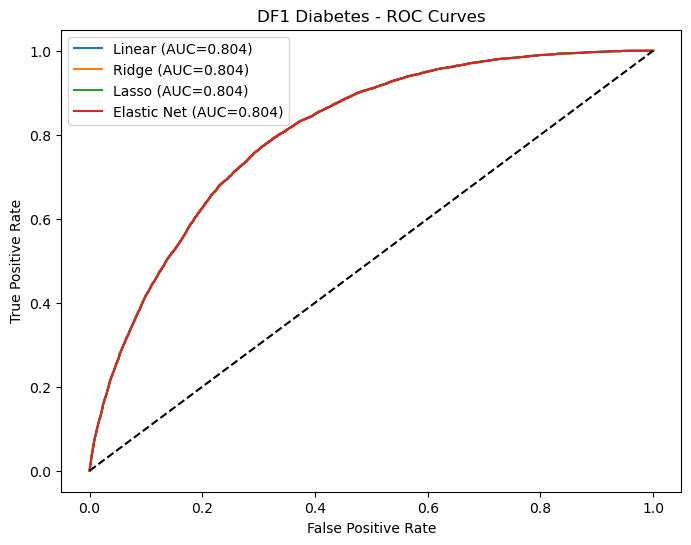

In [9]:
# compare all 4 models on roc curve
fig, ax = plt.subplots(figsize=(8, 6))

for name, prob in [('Linear', preds), ('Ridge', preds_ridge),
                   ('Lasso', preds_lasso), ('Elastic Net', preds_enet)]:
    fpr, tpr, _ = roc_curve(y1_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y1_test, prob):.3f})')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('DF1 Diabetes - ROC Curves')
ax.legend()
plt.show()

## Dataset 2 - Hospital Readmission

In [10]:
df2 = df2.dropna(subset=['readmitted'])
df2 = df2.fillna(0)

X2 = df2.drop(columns=['readmitted']).astype(float)
y2 = df2['readmitted']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=0)

scaler2 = StandardScaler()
X2_train = pd.DataFrame(scaler2.fit_transform(X2_train), columns=X2.columns)
X2_test = pd.DataFrame(scaler2.transform(X2_test), columns=X2.columns)

print(X2_train.shape, X2_test.shape)

(81412, 122) (20354, 122)


In [11]:
lr2 = LinearRegression()
lr2.fit(X2_train, y2_train)
p2_lr = lr2.predict(X2_test)
print('Linear AUC:', round(roc_auc_score(y2_test, p2_lr), 4))

ridge2 = Ridge(alpha=1.0)
ridge2.fit(X2_train, y2_train)
p2_ridge = ridge2.predict(X2_test)
print('Ridge AUC:', round(roc_auc_score(y2_test, p2_ridge), 4))

lasso2 = Lasso(alpha=0.001)
lasso2.fit(X2_train, y2_train)
p2_lasso = lasso2.predict(X2_test)
print('Lasso AUC:', round(roc_auc_score(y2_test, p2_lasso), 4))
print('Lasso features kept:', (lasso2.coef_ != 0).sum())

enet2 = ElasticNet(alpha=0.001, l1_ratio=0.5)
enet2.fit(X2_train, y2_train)
p2_enet = enet2.predict(X2_test)
print('Elastic Net AUC:', round(roc_auc_score(y2_test, p2_enet), 4))

Linear AUC: 0.6676
Ridge AUC: 0.6677
Lasso AUC: 0.6685
Lasso features kept: 66
Elastic Net AUC: 0.6684


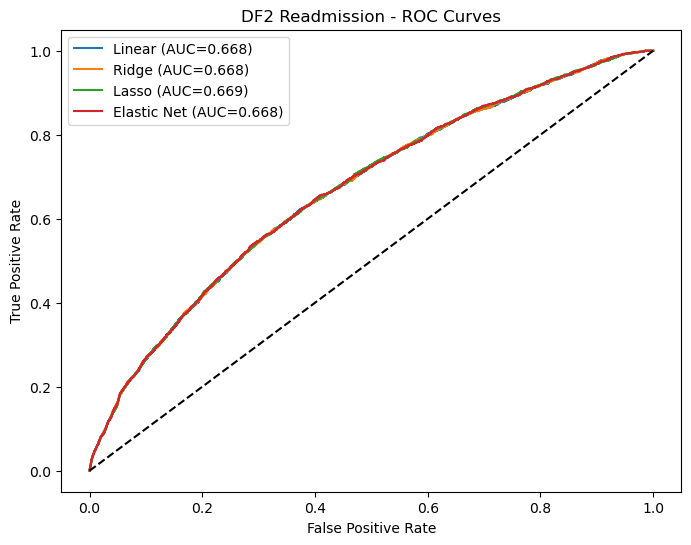

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, prob in [('Linear', p2_lr), ('Ridge', p2_ridge),
                   ('Lasso', p2_lasso), ('Elastic Net', p2_enet)]:
    fpr, tpr, _ = roc_curve(y2_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y2_test, prob):.3f})')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('DF2 Readmission - ROC Curves')
ax.legend()
plt.show()

## Dataset 3 - Stroke

In [13]:
df3 = df3.dropna()

X3 = df3.drop(columns=['stroke']).astype(float)
y3 = df3['stroke']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=0)

scaler3 = StandardScaler()
X3_train = pd.DataFrame(scaler3.fit_transform(X3_train), columns=X3.columns)
X3_test = pd.DataFrame(scaler3.transform(X3_test), columns=X3.columns)

print(X3_train.shape, X3_test.shape)
print('stroke rate:', round(y3.mean(), 3))

(4087, 17) (1022, 17)
stroke rate: 0.049


In [14]:
lr3 = LinearRegression()
lr3.fit(X3_train, y3_train)
p3_lr = lr3.predict(X3_test)
print('Linear AUC:', round(roc_auc_score(y3_test, p3_lr), 4))

ridge3 = Ridge(alpha=1.0)
ridge3.fit(X3_train, y3_train)
p3_ridge = ridge3.predict(X3_test)
print('Ridge AUC:', round(roc_auc_score(y3_test, p3_ridge), 4))

lasso3 = Lasso(alpha=0.001)
lasso3.fit(X3_train, y3_train)
p3_lasso = lasso3.predict(X3_test)
print('Lasso AUC:', round(roc_auc_score(y3_test, p3_lasso), 4))
print('Lasso features kept:', (lasso3.coef_ != 0).sum())

enet3 = ElasticNet(alpha=0.001, l1_ratio=0.5)
enet3.fit(X3_train, y3_train)
p3_enet = enet3.predict(X3_test)
print('Elastic Net AUC:', round(roc_auc_score(y3_test, p3_enet), 4))

Linear AUC: 0.8104
Ridge AUC: 0.8121
Lasso AUC: 0.8125
Lasso features kept: 13
Elastic Net AUC: 0.812


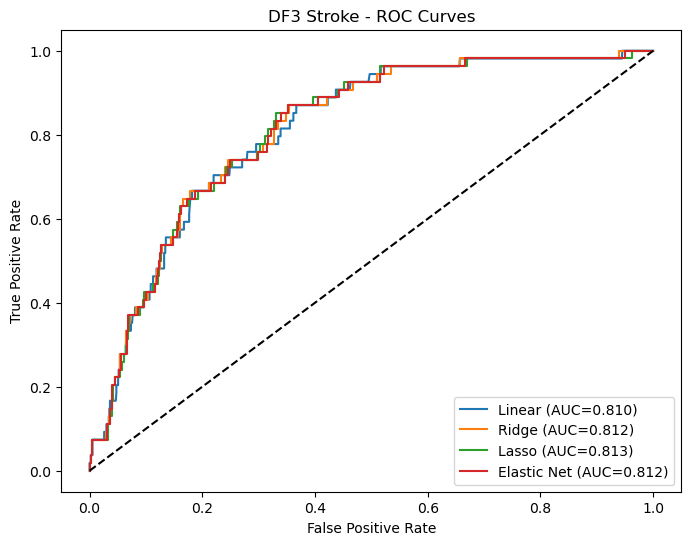

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, prob in [('Linear', p3_lr), ('Ridge', p3_ridge),
                   ('Lasso', p3_lasso), ('Elastic Net', p3_enet)]:
    fpr, tpr, _ = roc_curve(y3_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y3_test, prob):.3f})')

ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('DF3 Stroke - ROC Curves')
ax.legend()
plt.show()

## Summary

In [16]:
results = pd.DataFrame({
    'Model': ['Linear', 'Ridge', 'Lasso', 'Elastic Net'],
    'DF1 Diabetes': [
        round(roc_auc_score(y1_test, preds), 4),
        round(roc_auc_score(y1_test, preds_ridge), 4),
        round(roc_auc_score(y1_test, preds_lasso), 4),
        round(roc_auc_score(y1_test, preds_enet), 4)
    ],
    'DF2 Readmission': [
        round(roc_auc_score(y2_test, p2_lr), 4),
        round(roc_auc_score(y2_test, p2_ridge), 4),
        round(roc_auc_score(y2_test, p2_lasso), 4),
        round(roc_auc_score(y2_test, p2_enet), 4)
    ],
    'DF3 Stroke': [
        round(roc_auc_score(y3_test, p3_lr), 4),
        round(roc_auc_score(y3_test, p3_ridge), 4),
        round(roc_auc_score(y3_test, p3_lasso), 4),
        round(roc_auc_score(y3_test, p3_enet), 4)
    ]
})

print(results.to_string(index=False))

      Model  DF1 Diabetes  DF2 Readmission  DF3 Stroke
     Linear        0.8037           0.6676      0.8104
      Ridge        0.8037           0.6677      0.8121
      Lasso        0.8037           0.6685      0.8125
Elastic Net        0.8037           0.6684      0.8120
